## load data set

In [1]:
import pandas as pd

df = pd.read_csv("AI_Impact.csv")

## EDA


In [2]:
print("cek 5 data teratas\n")

df.head()

cek 5 data teratas



,Participant_ID,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,...,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Category,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
0,1,56,56-65,Female,No,22.2,Normal,Fitness Tracker,8,Medium,...,17,68,69,1,1.47,Improved,0.11,9,High,Low
1,2,69,66-79,Male,No,24.8,Normal,Fitness Tracker,8,Medium,...,19,51,63,12,23.53,Highly Improved,1.33,7,Medium,Low
2,3,46,46-55,Female,No,23.1,Normal,Mental Health App,8,Medium,...,12,57,72,15,26.32,Highly Improved,1.67,5,Medium,Low
3,4,32,26-35,Female,Yes,24.9,Normal,Fitness Tracker,16,High,...,17,83,99,16,19.28,Highly Improved,0.94,1,Low,Medium
4,5,60,56-65,Male,No,30.4,Obese,Fitness Tracker,11,Medium,...,12,41,39,-2,-4.88,Declined,-0.17,9,High,Medium


In [3]:
print("cek tipe data\n")

df.dtypes 


cek tipe data



Participant_ID                          int64
Age                                     int64
Age_Group                              object
Gender                                 object
Chronic_Condition                      object
BMI                                   float64
BMI_Category                           object
AI_Tool_Type                           object
AI_Health_App_Usage_Hours_Per_Week      int64
AI_Usage_Level                         object
Exercise_Hours_Per_Week                 int64
Exercise_Level                         object
Total_Engagement_Hours_Per_Week         int64
Health_Score_Before_AI                  int64
Health_Score_After_AI                   int64
Improvement                             int64
Improvement_Percentage                float64
Improvement_Category                   object
Improvement_Per_AI_Hour               float64
Satisfaction_Score                      int64
Satisfaction_Level                     object
Risk_Category                     

In [4]:
print("cek tipe data\n")

df.isnull().sum()

cek tipe data



Participant_ID                        0
Age                                   0
Age_Group                             0
Gender                                0
Chronic_Condition                     0
BMI                                   0
BMI_Category                          0
AI_Tool_Type                          0
AI_Health_App_Usage_Hours_Per_Week    0
AI_Usage_Level                        0
Exercise_Hours_Per_Week               0
Exercise_Level                        0
Total_Engagement_Hours_Per_Week       0
Health_Score_Before_AI                0
Health_Score_After_AI                 0
Improvement                           0
Improvement_Percentage                0
Improvement_Category                  0
Improvement_Per_AI_Hour               0
Satisfaction_Score                    0
Satisfaction_Level                    0
Risk_Category                         0
dtype: int64

## cek outlier

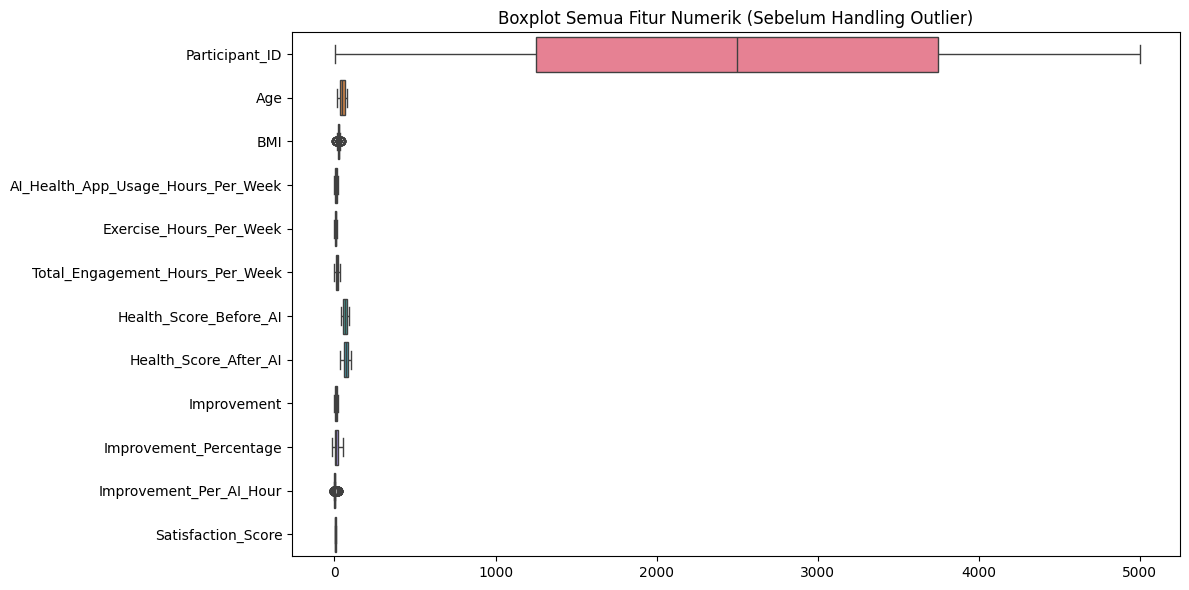

Jumlah outlier per kolom sebelum handling:
Participant_ID: 0
Age: 0
BMI: 43
AI_Health_App_Usage_Hours_Per_Week: 0
Exercise_Hours_Per_Week: 0
Total_Engagement_Hours_Per_Week: 0
Health_Score_Before_AI: 0
Health_Score_After_AI: 0
Improvement: 0
Improvement_Percentage: 0
Improvement_Per_AI_Hour: 496
Satisfaction_Score: 0


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # invalid -> NaN

df[num_cols] = df[num_cols].fillna(df[num_cols].median())


plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], orient='h')
plt.title("Boxplot Semua Fitur Numerik (Sebelum Handling Outlier)")
plt.tight_layout()
plt.show()

outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outliers

print("Jumlah outlier per kolom sebelum handling:")
for k, v in outlier_summary.items():
    print(f"{k}: {v}")


## train test split

In [6]:
from sklearn.model_selection import train_test_split

# Daftar kolom yang bisa membuat model "mencontek" kunci jawaban
kolom_bocor = [
    "Health_Score_Before_AI", 
    "Health_Score_After_AI", 
    "Improvement", 
    "Improvement_Percentage", 
    "Participant_ID"
]

X = df.drop(columns=["Improvement_Category"] + kolom_bocor)
y = df["Improvement_Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Encoding

In [7]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

X_train_final = pd.concat([X_train.drop(columns=categorical_cols), train_encoded_df], axis=1)
X_test_final = pd.concat([X_test.drop(columns=categorical_cols), test_encoded_df], axis=1)


## modeling

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score ,classification_report, confusion_matrix

# Model
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# training
model.fit(X_train_final,y_train)

# prediction
y_pred=model.predict(X_test_final)

# evaluasi
acc = accuracy_score(y_test, y_pred)

print("accuracy: ", acc)
print(classification_report(y_test,y_pred))

print("\nconfusion matrix : \n")
print(confusion_matrix(y_test,y_pred))

accuracy:  0.943
                 precision    recall  f1-score   support

       Declined       1.00      1.00      1.00       206
Highly Improved       0.91      0.95      0.93       381
       Improved       0.94      0.90      0.92       376
      No Change       1.00      0.95      0.97        37

       accuracy                           0.94      1000
      macro avg       0.96      0.95      0.96      1000
   weighted avg       0.94      0.94      0.94      1000


confusion matrix : 

[[206   0   0   0]
 [  0 362  19   0]
 [  0  36 340   0]
 [  0   0   2  35]]


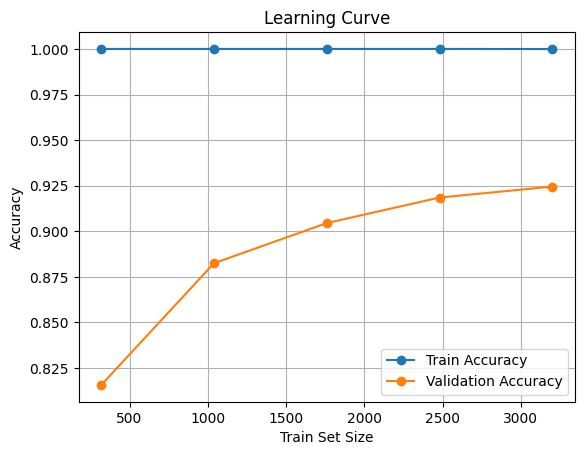

In [17]:
# learning curve
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
	
train_sizes, train_scores, val_scores = learning_curve(
	model, X_train_final, y_train, cv=5, scoring='accuracy'
)
	
# Rata-rata accuracy
train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)
	
plt.plot(train_sizes, train_scores_mean, 'o-', label="Train Accuracy")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation Accuracy")
plt.legend()
plt.xlabel("Train Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.grid()
plt.show()
	

Overall ROC-AUC: 0.9877


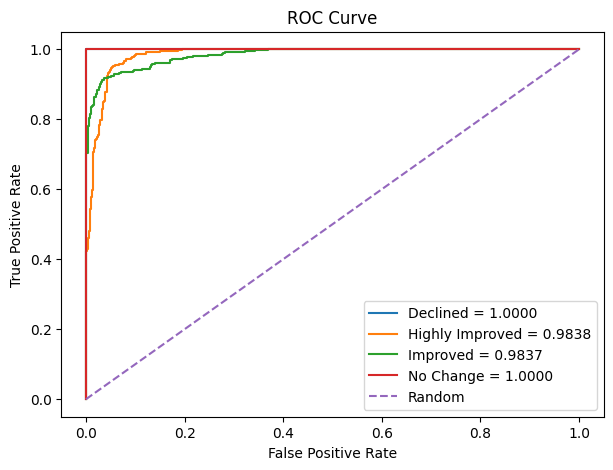

In [18]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# Probabilitas prediksi
y_prob = model.predict_proba(X_test_final)
classes = model.classes_

plt.figure(figsize=(7, 5))

# ==========================
# BINARY CLASSIFICATION
# ==========================
if len(classes) == 2:

    # Probabilitas kelas positif
    y_score = y_prob[:, 1]

    # Hitung ROC-AUC
    roc_auc = roc_auc_score(y_test, y_score)

    # Hitung ROC Curve
    fpr, tpr, _ = roc_curve(
        y_test,
        y_score,
        pos_label=classes[1]
    )

    # Plot ROC
    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {roc_auc:.4f}"
    )

# ==========================
# MULTICLASS CLASSIFICATION
# ==========================
else:

    # Overall ROC-AUC (One-vs-Rest)
    roc_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    # Binarisasi label
    y_test_bin = label_binarize(
        y_test,
        classes=classes
    )

    # ROC tiap kelas
    for i, class_name in enumerate(classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_prob[:, i]
        )

        class_auc = roc_auc_score(
            y_test_bin[:, i],
            y_prob[:, i]
        )

        plt.plot(
            fpr,
            tpr,
            label=f"{class_name} = {class_auc:.4f}"
        )

# ==========================
# HASIL
# ==========================
print(f"Overall ROC-AUC: {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], "--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()